In [ ]:
!pip install torchinfo

In [ ]:
# --- 1. Setup & Imports ---
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print('Importing completed...\n')

Using device: cuda



100%|██████████| 9.91M/9.91M [00:00<00:00, 48.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]

Importing completed...



In [ ]:
# --- 2. Build Original CNN ---
cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
).to(device)

print('Model understood...')

Model understood...


In [ ]:
# --- 3. Training Loop ---
loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
epochs = 5

print("Training in progress...")
for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        loss = loss_fn(outputs, labels)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs} | Error Rate (Loss): {average_loss:.4f}")
print("Training Complete...\n")

Training in progress...
Epoch 1/5 | Error Rate (Loss): 0.1640
Epoch 2/5 | Error Rate (Loss): 0.0469
Epoch 3/5 | Error Rate (Loss): 0.0321
Epoch 4/5 | Error Rate (Loss): 0.0250
Epoch 5/5 | Error Rate (Loss): 0.0172
Training Complete...



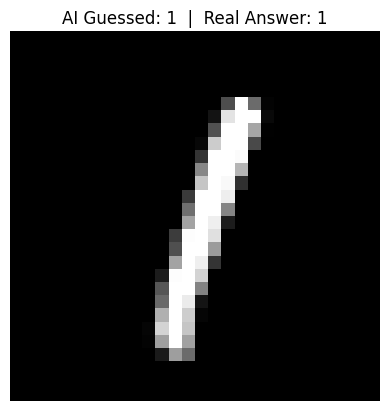

Single test for reference complete...



In [ ]:
# --- 4. Single Image Test ---
images, real_answer = test_dataset[5]
with torch.no_grad():
    preds = cnn_model(images.unsqueeze(0).to(device))
answer = torch.argmax(preds).item()

plt.imshow(images.squeeze().cpu(), cmap='grey')
plt.title(f"AI Guessed: {answer}  |  Real Answer: {real_answer}")
plt.axis('off')
plt.show()

print("Single test for reference complete...\n")

In [ ]:
# --- 5. Original Model Evaluation ---
cnn_model.eval()
correct_guesses = 0
total_images = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        _, preds = torch.max(outputs, dim=1)

        total_images += labels.size(0)
        correct_guesses += (preds == labels).sum().item()

cnn_accuracy = 100 * correct_guesses / total_images

print(f"Final Score: The CNN guessed correctly {correct_guesses} out of {total_images} times.")
print(f"CNN Accuracy: {cnn_accuracy:.2f}%\n")

Final Score: The CNN guessed correctly 9885 out of 10000 times.
CNN Accuracy: 98.85%



In [ ]:
# --- 6. Summary for CNN ---
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

summary(cnn_model, input_size=(1, 1, 28, 28), col_names=("num_params", "mult_adds"))

Total Parameters: 421,642
Trainable Parameters: 421,642


Layer (type:depth-idx)                   Param #                   Mult-Adds
Sequential                               --                        --
├─Conv2d: 1-1                            320                       250,880
├─ReLU: 1-2                              --                        --
├─MaxPool2d: 1-3                         --                        --
├─Conv2d: 1-4                            18,496                    3,625,216
├─ReLU: 1-5                              --                        --
├─MaxPool2d: 1-6                         --                        --
├─Flatten: 1-7                           --                        --
├─Linear: 1-8                            401,536                   401,536
├─ReLU: 1-9                              --                        --
├─Linear: 1-10                           1,290                     1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.28
Input size (MB): 0.00

In [ ]:
# 1. Structural Dense Layer Compression (Updated Energy SVD)
def energy_svd_lin_layer(linear_layer, tau=0.90):
    W = linear_layer.weight.data
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    energy = S ** 2
    total_energy = torch.sum(energy)
    cumulative_energy = torch.cumsum(energy, dim=0) / total_energy
    k = torch.where(cumulative_energy >= tau)[0][0].item() + 1

    # The Safety Net
    original_params = linear_layer.in_features * linear_layer.out_features
    new_params = (linear_layer.in_features * k) + (k * linear_layer.out_features)

    if new_params >= original_params:
        print(f" -> ABORTED: Rank {k} is too large. Keeping original Linear layer.")
        return linear_layer

    linear_A = nn.Linear(linear_layer.in_features, k, bias=False).to(device)
    linear_A.weight.data = Vh[:k, :]
    linear_B = nn.Linear(k, linear_layer.out_features, bias=True).to(device)
    linear_B.weight.data = U[:, :k] @ torch.diag(S[:k])

    if linear_layer.bias is not None:
        linear_B.bias.data = linear_layer.bias.data

    print(f" -> Energy SVD: Kept {tau*100}% energy | Auto-selected Rank: {k}")
    return nn.Sequential(linear_A, linear_B)

# 2. Structural Convolutional Layer Compression (Updated Energy SVD)
def energy_svd_conv_layer(conv_layer, tau=0.90):
    W = conv_layer.weight.data
    out_c, in_c, k_h, k_w = W.shape

    W_2d = W.view(out_c, -1)
    U, S, Vh = torch.linalg.svd(W_2d, full_matrices=False)

    # --- UPDATED ENERGY MATH (sigma^4) ---
    energy = S ** 2
    total_energy = torch.sum(energy)
    cumulative_energy = torch.cumsum(energy, dim=0)

    target = tau * total_energy
    k = torch.where(cumulative_energy >= target)[0][0].item() + 1
    # -------------------------------------

    # The Safety Net
    original_params = in_c * out_c * k_h * k_w
    new_params = (in_c * k * k_h * k_w) + (k * out_c * 1 * 1)

    if new_params >= original_params:
        print(f" -> ABORTED: Rank {k} is too large. Keeping original Conv2d layer.")
        return conv_layer

    ConvA = nn.Conv2d(in_channels=in_c, out_channels=k, kernel_size=(k_h, k_w),
                      stride=conv_layer.stride, padding=conv_layer.padding, bias=False).to(device)

    Vh_k = Vh[:k, :]
    ConvA.weight.data = Vh_k.view(k, in_c, k_h, k_w)

    ConvB = nn.Conv2d(in_channels=k, out_channels=out_c, kernel_size=1, bias=True).to(device)

    U_k = U[:, :k]
    S_k = torch.diag(S[:k])
    US_k = U_k @ S_k

    ConvB.weight.data = US_k.view(out_c, k, 1, 1)

    if conv_layer.bias is not None:
        ConvB.bias.data = conv_layer.bias.data

    print(f" -> Energy SVD: Kept {tau*100}% energy | Auto-selected Rank: {k}")
    return nn.Sequential(ConvA, ConvB)

In [ ]:
# --- 10. Algorithm 2 ---
print("Starting Adaptive-Rank Neural Network Compression...\n")
tau = 0.90
comp_cnn = copy.deepcopy(cnn_model)
new_layer = []

# Variables to store our optimal k values
k1 = 0 # For FC1
k2 = 0 # For Conv2

for index, layer in enumerate(comp_cnn):
    if isinstance(layer, nn.Linear) and index == 7:
        print(f"Compressing Layer {index} (Linear): {layer.in_features}x{layer.out_features}")
        comp_layer = energy_svd_lin_layer(layer, tau)

        # Capture k1 from the new Linear_A bottleneck
        k1 = comp_layer[0].out_features

        new_layer.append(comp_layer)

    elif isinstance(layer, nn.Conv2d) and index == 3:
        print(f"Compressing Layer {index} (Conv2d): {layer.in_channels} -> {layer.out_channels} channels")
        comp_layer = energy_svd_conv_layer(layer, tau)

        # Capture k2 from the new ConvA bottleneck (Safety Net Check)
        if isinstance(comp_layer, nn.Sequential):
            k2 = comp_layer[0].out_channels
        else:
            k2 = layer.out_channels # If it aborted, k is just the original channel size

        new_layer.append(comp_layer)

    else:
        new_layer.append(layer)

final_comp_cnn = nn.Sequential(*new_layer).to(device)
print("\nCompression Complete!")

total_param_original = sum(p.numel() for p in cnn_model.parameters())
total_param_comp = sum(p.numel() for p in final_comp_cnn.parameters())
print("\n--- Hardware Efficiency Results ---")
print(f"Original Parameters:   {total_param_original:,}")
print(f"Compressed Parameters: {total_param_comp:,}")

percent_saved = 100 * (1 - (total_param_comp / total_param_original))
print(f"Total Model Reduction: {percent_saved:.2f}% smaller!")

print("\n--- Final Compressed Model Summary ---")
summary(final_comp_cnn, input_size=(1, 1, 28, 28), col_names=("num_params", "mult_adds"), device=device)

Starting Adaptive-Rank Neural Network Compression...

Compressing Layer 3 (Conv2d): 32 -> 64 channels
 -> Energy SVD: Kept 90.0% energy | Auto-selected Rank: 26
Compressing Layer 7 (Linear): 3136x128
 -> Energy SVD: Kept 90.0% energy | Auto-selected Rank: 39

Compression Complete!

--- Hardware Efficiency Results ---
Original Parameters:   421,642
Compressed Parameters: 138,250
Total Model Reduction: 67.21% smaller!

--- Final Compressed Model Summary ---


Layer (type:depth-idx)                   Param #                   Mult-Adds
Sequential                               --                        --
├─Conv2d: 1-1                            320                       250,880
├─ReLU: 1-2                              --                        --
├─MaxPool2d: 1-3                         --                        --
├─Sequential: 1-4                        --                        --
│    └─Conv2d: 2-1                       7,488                     1,467,648
│    └─Conv2d: 2-2                       1,728                     338,688
├─ReLU: 1-5                              --                        --
├─MaxPool2d: 1-6                         --                        --
├─Flatten: 1-7                           --                        --
├─Sequential: 1-8                        --                        --
│    └─Linear: 2-3                       122,304                   122,304
│    └─Linear: 2-4                       5,120               

In [ ]:
final_comp_cnn.eval()

correct_guesses = 0
total_images = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = final_comp_cnn(images)
        _, preds = torch.max(outputs, dim=1)

        total_images += labels.size(0)
        correct_guesses += (preds == labels).sum().item()

comp_cnn_accuracy = 100 * correct_guesses / total_images

orig_stats = summary(cnn_model, input_size=(1, 1, 28, 28), verbose=0)
comp_stats = summary(final_comp_cnn, input_size=(1, 1, 28, 28), verbose=0)

orig_flops = orig_stats.total_mult_adds
comp_flops = comp_stats.total_mult_adds
orig_params = orig_stats.total_params
comp_params = comp_stats.total_params

print("\n================ FINAL COMPARISON (Both Convolution and FC1 layer) ================")
print(f"Original Accuracy:   {cnn_accuracy:.2f}%")
print(f"Compressed Accuracy: {comp_cnn_accuracy:.2f}%")
print(f"-> Accuracy Drop:    {cnn_accuracy - comp_cnn_accuracy:.2f}%\n")

print(f"Original Parameters:   {orig_params:,}")
print(f"Compressed Parameters: {comp_params:,}")
print(f"-> Memory Saved:       {100 * (1 - comp_params / orig_params):.2f}%\n")

print(f"Original FLOPs (MACs):   {orig_flops:,}")
print(f"Compressed FLOPs (MACs): {comp_flops:,}")
print(f"-> Compute Saved:        {100 * (1 - comp_flops / orig_flops):.2f}%")
print("=============================================================")


================ FINAL COMPARISON (Both Convolution and FC1 layer) ================
Original Accuracy:   98.85%
Compressed Accuracy: 98.87%
-> Accuracy Drop:    -0.02%

Original Parameters:   421,642
Compressed Parameters: 138,250
-> Memory Saved:       67.21%

Original FLOPs (MACs):   4,278,922
Compressed FLOPs (MACs): 2,185,930
-> Compute Saved:        48.91%


Running final speed benchmarks...
Original Time: 1.1165s | Compressed Time: 1.2183s



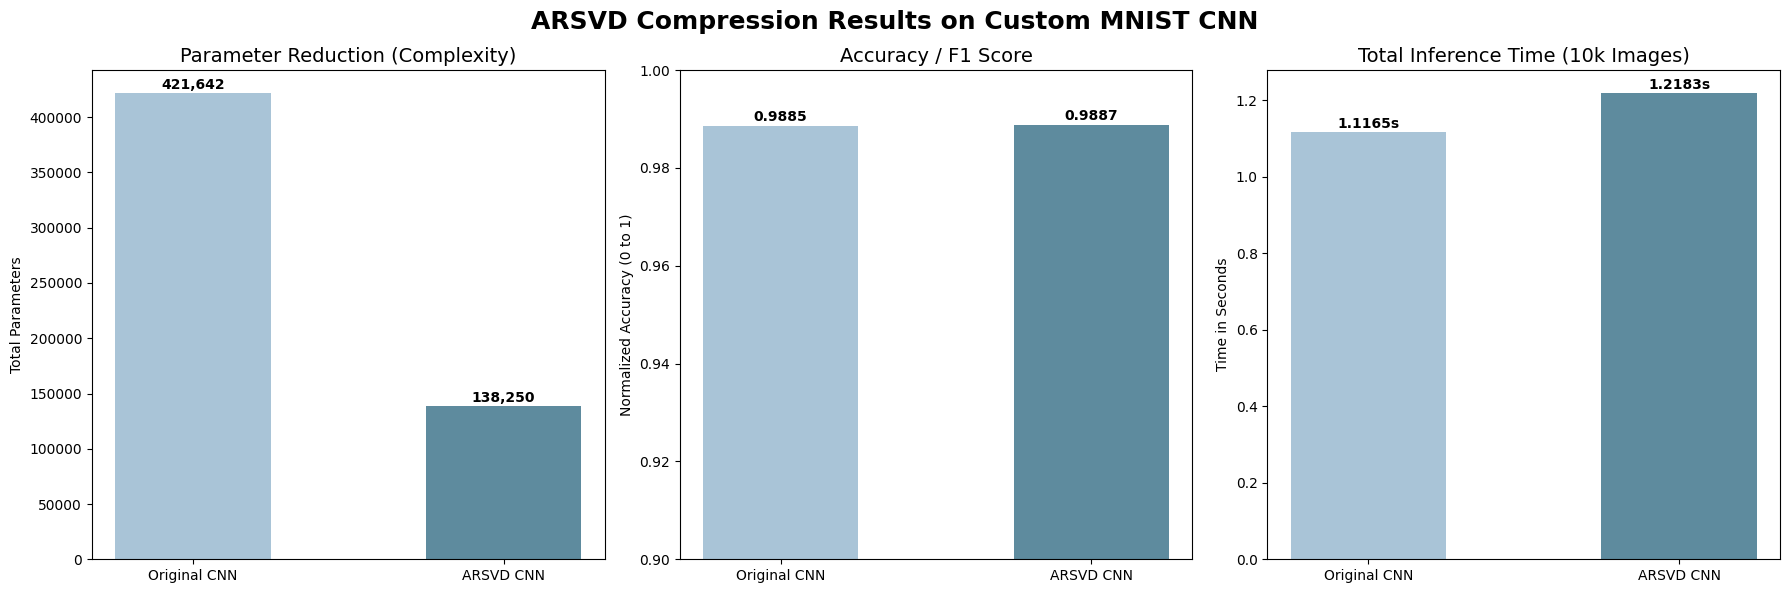

In [ ]:
# --- 12. Experimental Result ---
import time
import matplotlib.pyplot as plt
import numpy as np

print("Running final speed benchmarks...")

# --- 1. Measure Inference Time ---
cnn_model.eval()
final_comp_cnn.eval()

# Time the Original Model
start_time = time.time()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _ = cnn_model(images)
original_time = time.time() - start_time

# Time the Compressed Model
start_time = time.time()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _ = final_comp_cnn(images)
compressed_time = time.time() - start_time

print(f"Original Time: {original_time:.4f}s | Compressed Time: {compressed_time:.4f}s\n")

# --- Plotting the Data ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ARSVD Compression Results on Custom MNIST CNN', fontsize=18, fontweight='bold')

labels = ['Original CNN', 'ARSVD CNN']
colors = ['#A9C4D7', '#5E8B9E']

# Graph 1: Parameter Reduction
params_data = [orig_params, comp_params]
axes[0].bar(labels, params_data, color=colors, width=0.5)
axes[0].set_title('Parameter Reduction (Complexity)', fontsize=14)
axes[0].set_ylabel('Total Parameters')

for i, v in enumerate(params_data):
    axes[0].text(i, v + (orig_params*0.01), f"{v:,}", ha='center', fontweight='bold')

# Graph 2: Accuracy Preservation
acc_data = [cnn_accuracy / 100, comp_cnn_accuracy / 100]
axes[1].bar(labels, acc_data, color=colors, width=0.5)
axes[1].set_title('Accuracy / F1 Score', fontsize=14)
axes[1].set_ylabel('Normalized Accuracy (0 to 1)')
axes[1].set_ylim(0.9, 1.0)
for i, v in enumerate(acc_data):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

# Graph 3: Inference Time
time_data = [original_time, compressed_time]
axes[2].bar(labels, time_data, color=colors, width=0.5)
axes[2].set_title('Total Inference Time (10k Images)', fontsize=14)
axes[2].set_ylabel('Time in Seconds')
for i, v in enumerate(time_data):
    axes[2].text(i, v + (original_time*0.01), f"{v:.4f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [ ]:
# --- Healing Phase: Fine-Tuning the Compressed Model ---
print("Starting Fine-Tuning to recover accuracy...")

# Use a learning rate 10x smaller than the baseline so we don't ruin the SVD weights!
healing_optimizer = torch.optim.Adam(final_comp_cnn.parameters(), lr=0.00001)
healing_epochs = 5

final_comp_cnn.train()
for epoch in range(healing_epochs):
    running_loss = 0
    start_heal = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = final_comp_cnn(images)
        loss = loss_fn(outputs, labels)

        healing_optimizer.zero_grad()
        loss.backward()
        healing_optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    heal_time = time.time() - start_heal
    print(f"Healing Epoch {epoch + 1}/{healing_epochs} | Loss: {average_loss:.4f} | Time: {heal_time:.2f}s")

print("Healing Complete! Re-evaluating...\n")

# --- Post-Healing Accuracy Check ---
final_comp_cnn.eval()
heal_correct, heal_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_comp_cnn(images)
        _, preds = torch.max(outputs, dim=1)
        heal_total += labels.size(0)
        heal_correct += (preds == labels).sum().item()

healed_accuracy = 100 * heal_correct / heal_total

print("================ HEALED MODEL REPORT (Both Convolutional and FC1 layer) ================")
print(f"ESVD Threshold (Tau):             {tau}")
print(f"Optimal Rank (k1) for FC1:        {k1} (out of 128)")
print(f"Optimal Rank (k2) for Conv:       {k2} (out of 64)\n")

print(f"Baseline Accuracy:                {cnn_accuracy:.2f}%")
print(f"Raw Compressed Accuracy:          {comp_cnn_accuracy:.2f}%")
print(f"Healed Accuracy:                  {healed_accuracy:.2f}%")
print("==================================================================")

Starting Fine-Tuning to recover accuracy...
Healing Epoch 1/5 | Loss: 0.0100 | Time: 10.86s
Healing Epoch 2/5 | Loss: 0.0072 | Time: 9.80s
Healing Epoch 3/5 | Loss: 0.0063 | Time: 9.36s
Healing Epoch 4/5 | Loss: 0.0057 | Time: 9.79s
Healing Epoch 5/5 | Loss: 0.0052 | Time: 9.77s
Healing Complete! Re-evaluating...

================ HEALED MODEL REPORT (Both Convolutional and FC1 layer) ================
ESVD Threshold (Tau):             0.9
Optimal Rank (k1) for FC1:        39 (out of 128)
Optimal Rank (k2) for Conv:       26 (out of 64)

Baseline Accuracy:                98.85%
Raw Compressed Accuracy:          98.87%
Healed Accuracy:                  99.30%
